# Phase 3 — Model Comparison

Built on the Phase 2 baseline (Random Forest, F1 Macro=0.845).  
The same preprocessing + SMOTE pipeline is used; only the model changes.

**Problematic classes (from Phase 2):** Bot (F1=0.41, precision=0.26), XSS (0.47), Brute Force (0.72)  
**Target:** F1 Macro ≥ 0.90

| Step | Content |
|------|--------|
| 1 | Load Phase 2 artifacts (preprocessor, label_encoder) |
| 2 | Same train/test split + SMOTE |
| 3 | XGBoost |
| 4 | LightGBM |
| 5 | Logistic Regression (lower bound) |
| 6 | Comparison table + visualisation |

In [1]:
# ── Package installation (run once in Colab) ───────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import xgboost
except ImportError:
    install("xgboost")

try:
    import lightgbm
except ImportError:
    install("lightgbm")

try:
    import imblearn
except ImportError:
    install("imbalanced-learn")

try:
    import cuml
except ImportError:
    install("cuml-cu12 --extra-index-url=https://pypi.nvidia.com")

print("Packages ready.")

Packages ready.


In [2]:
import pandas as pd
import numpy as np
import joblib
import json
import time
import warnings
from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Google Colab / Drive setup ─────────────────────────────────────────
try:
    import google.colab  # type: ignore
    IN_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUTS = Path('/content/drive/MyDrive/nids/outputs')
except ImportError:
    IN_COLAB = False
    OUTPUTS = Path('../outputs')

RESULTS_DIR = OUTPUTS / "results"
MODELS_DIR  = OUTPUTS / "models"
FIGURES_DIR = OUTPUTS / "figures"
for d in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SMOTE_TARGET = 5_000

print(f"OUTPUTS → {OUTPUTS}  ({'Colab + Drive' if IN_COLAB else 'Local'})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUTPUTS → /content/drive/MyDrive/nids/outputs  (Colab + Drive)


## 1. Load Phase 2 Artifacts

Preprocessor and label encoder were trained and saved in Phase 2.  
No need to retrain here — we load them directly.

In [3]:
# Load artifacts saved in Phase 2
preprocessor = joblib.load(MODELS_DIR / "preprocessor.joblib")
le           = joblib.load(MODELS_DIR / "label_encoder.joblib")

with open(RESULTS_DIR / "kept_features.json") as f:
    kept_cols = json.load(f)

print(f"Preprocessor loaded  → {len(kept_cols)} features")
print(f"Label encoder loaded → {len(le.classes_)} classes")
print(f"\nClasses:")
for i, cls in enumerate(le.classes_):
    print(f"  {i:2d} → {cls}")

Preprocessor loaded  → 67 features
Label encoder loaded → 15 classes

Classes:
   0 → BENIGN
   1 → Bot
   2 → DDoS
   3 → DoS GoldenEye
   4 → DoS Hulk
   5 → DoS Slowhttptest
   6 → DoS slowloris
   7 → FTP-Patator
   8 → Heartbleed
   9 → Infiltration
  10 → PortScan
  11 → SSH-Patator
  12 → Web Attack � Brute Force
  13 → Web Attack � Sql Injection
  14 → Web Attack � XSS


## 2. Data + Train/Test Split + SMOTE

The **exact same** `random_state` and `test_size` as Phase 2 are used → the comparison is valid.

In [4]:
SAMPLE_FRAC = 0.30   # Colab RAM limit — 30% sufficient for comparison

df = pd.read_parquet(OUTPUTS / "cicids2017_clean.parquet")
df = df.groupby("Label", group_keys=False).apply(
    lambda g: g.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
)
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}  (sample_frac={SAMPLE_FRAC})")

feature_cols = [c for c in df.columns if c not in ("Label", "label_enc")]
df["label_enc"] = le.transform(df["Label"])
X = df[feature_cols]
y = df["label_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Apply preprocessor (no fit — using the fit from Phase 2)
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"\nTrain: {X_train_proc.shape}  |  Test: {X_test_proc.shape}")

Rows: 756,239  |  Columns: 72  (sample_frac=0.3)

Train: (604991, 67)  |  Test: (151248, 67)


In [5]:
# ── SMOTE (same strategy as Phase 2) ──────────────────────────────────────
class_counts   = Counter(y_train.tolist())
majority_class = max(class_counts, key=class_counts.get)

sampling_strategy = {
    cls_idx: SMOTE_TARGET
    for cls_idx, count in class_counts.items()
    if cls_idx != majority_class and count < SMOTE_TARGET
}

min_minority_count = min(class_counts[cls] for cls in sampling_strategy)
k_neighbors = min(5, min_minority_count - 1)

smote = SMOTE(
    sampling_strategy=sampling_strategy,
    k_neighbors=k_neighbors,
    random_state=RANDOM_STATE,
)

print(f"Applying SMOTE... ({X_train_proc.shape[0]:,} rows)")
t0 = time.time()
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)
print(f"Complete!  Time: {time.time()-t0:.1f}s")
print(f"Shape: {X_train_proc.shape} → {X_train_smote.shape}  "
      f"(+{X_train_smote.shape[0]-X_train_proc.shape[0]:,} sentetik)")

Applying SMOTE... (604,991 rows)
Complete!  Time: 0.7s
Shape: (604991, 67) → (651786, 67)  (+46,795 sentetik)


## 3. Helper Function — Model Evaluation

The same metrics are computed for each model and results are appended to `all_results`.

In [6]:
all_results = []  # all model results are accumulated here

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, label_encoder):
    """Train the model, evaluate on the test set, return and print results."""
    print(f"\n{'═'*52}")
    print(f"  {name}")
    print(f"{'═'*52}")

    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)

    acc     = accuracy_score(y_te, y_pred)
    f1_mac  = f1_score(y_te, y_pred, average="macro",    zero_division=0)
    f1_wei  = f1_score(y_te, y_pred, average="weighted", zero_division=0)
    roc_auc = roc_auc_score(y_te, y_prob, multi_class="ovr", average="weighted")

    print(f"  Training time  : {train_time/60:.1f} minutes")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  F1 Macro       : {f1_mac:.4f}")
    print(f"  F1 Weighted    : {f1_wei:.4f}")
    print(f"  ROC-AUC (ovr-w): {roc_auc:.4f}")

    print(f"\n─── Classification Report ───")
    print(classification_report(
        y_te, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0,
    ))

    result = {
        "model":        name,
        "accuracy":     acc,
        "f1_macro":     f1_mac,
        "f1_weighted":  f1_wei,
        "roc_auc":      roc_auc,
        "train_time_m": round(train_time / 60, 2),
    }
    all_results.append(result)
    return model, result

print("evaluate_model() ready.")

evaluate_model() ready.


## 4. XGBoost

- No `sample_weight` in place of `scale_pos_weight` — class weights are already balanced by SMOTE  
- `tree_method='hist'` → fast on Colab CPU  
- `eval_metric='mlogloss'` → standard for multiclass

In [7]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    tree_method="hist",      # hist + device=cuda → GPU on Colab
    device="cuda",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0,
)

xgb_model, xgb_result = evaluate_model(
    "XGBoost", xgb,
    X_train_smote, y_train_smote,
    X_test_proc,   y_test,
    le,
)

joblib.dump(xgb_model, MODELS_DIR / "xgboost_comparison.joblib")
print(f"\nModel saved → {MODELS_DIR / 'xgboost_comparison.joblib'}")


════════════════════════════════════════════════════
  XGBoost
════════════════════════════════════════════════════
  Training time  : 0.8 minutes
  Accuracy       : 0.9987
  F1 Macro       : 0.8593
  F1 Weighted    : 0.9987
  ROC-AUC (ovr-w): 1.0000

─── Classification Report ───
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    125703
                       Bot       0.75      0.91      0.83       117
                      DDoS       1.00      1.00      1.00      7681
             DoS GoldenEye       1.00      1.00      1.00       617
                  DoS Hulk       1.00      1.00      1.00     10371
          DoS Slowhttptest       0.99      0.99      0.99       314
             DoS slowloris       0.99      0.99      0.99       323
               FTP-Patator       1.00      1.00      1.00       356
                Heartbleed       1.00      1.00      1.00         1
              Infiltration       1.0

## 5. LightGBM

- Much faster compared to RF and XGBoost  
- `num_leaves=63` → controlled by number of leaves instead of depth  
- `min_child_samples=20` → kept small for rare classes

In [8]:
lgbm = LGBMClassifier(
    n_estimators=300,
    num_leaves=63,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)

lgbm_model, lgbm_result = evaluate_model(
    "LightGBM", lgbm,
    X_train_smote, y_train_smote,
    X_test_proc,   y_test,
    le,
)

joblib.dump(lgbm_model, MODELS_DIR / "lightgbm_comparison.joblib")
print(f"\nModel saved → {MODELS_DIR / 'lightgbm_comparison.joblib'}")


════════════════════════════════════════════════════
  LightGBM
════════════════════════════════════════════════════
  Training time  : 6.2 minutes
  Accuracy       : 0.7490
  F1 Macro       : 0.0747
  F1 Weighted    : 0.7360
  ROC-AUC (ovr-w): 0.5448

─── Classification Report ───
                            precision    recall  f1-score   support

                    BENIGN       0.85      0.89      0.87    125703
                       Bot       0.00      0.00      0.00       117
                      DDoS       0.00      0.00      0.00      7681
             DoS GoldenEye       0.05      0.07      0.06       617
                  DoS Hulk       1.00      0.11      0.19     10371
          DoS Slowhttptest       0.00      0.00      0.00       314
             DoS slowloris       0.00      0.00      0.00       323
               FTP-Patator       0.00      0.00      0.00       356
                Heartbleed       0.00      0.00      0.00         1
              Infiltration       0.

## 6. Logistic Regression (Lower Bound)

A linear lower bound to see whether gradient boosting models genuinely add value.  
`solver='saga'` + `max_iter=200` is sufficient for 2M+ rows.

In [9]:
from cuml.linear_model import LogisticRegression as cuLR

lr = cuLR(
    max_iter=200,
    solver="qn",             # cuML supports: qn, sgd, cd
    penalty="l2",
    C=1.0,
    class_weight="balanced",
)

lr_model, lr_result = evaluate_model(
    "Logistic Regression", lr,
    X_train_smote, y_train_smote,
    X_test_proc,   y_test,
    le,
)

joblib.dump(lr_model, MODELS_DIR / "logreg_comparison.joblib")
print(f"\nModel saved → {MODELS_DIR / 'logreg_comparison.joblib'}")


════════════════════════════════════════════════════
  Logistic Regression
════════════════════════════════════════════════════
[2026-05-03 12:10:20.761] [CUML] [warning] L-BFGS: max iterations reached
[2026-05-03 12:10:20.761] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  Training time  : 0.3 minutes
  Accuracy       : 0.9729
  F1 Macro       : 0.6670
  F1 Weighted    : 0.9760
  ROC-AUC (ovr-w): 0.9965

─── Classification Report ───
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.98      0.98    125703
                       Bot       0.62      0.38      0.47       117
                      DDoS       0.99      0.98      0.99      7681
             DoS GoldenEye       0.93      0.89      0.91       617
                  DoS Hulk       1.00      0.94      0.97     10371
  

## 7. Comparison Table

The Phase 2 Random Forest baseline result is also added to the table.

In [10]:
# Add Phase 2 RF result to the table (hardcoded — from Phase 2 output)
rf_baseline = {
    "model":        "Random Forest (Phase 2 baseline)",
    "accuracy":     0.9966,
    "f1_macro":     0.8449,
    "f1_weighted":  0.9973,
    "roc_auc":      1.0000,
    "train_time_m": 18.0,
}

comparison_df = pd.DataFrame([rf_baseline] + all_results)
comparison_df = comparison_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)

# Kaydet
comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)

# Pretty table
display_cols = ["model", "f1_macro", "f1_weighted", "accuracy", "roc_auc", "train_time_m"]
print("\n═══ Model Comparison (F1 Macro — descending) ═══")
print(comparison_df[display_cols].to_string(index=False))
print(f"\nKaydedildi → {RESULTS_DIR / 'model_comparison.csv'}")


═══ Model Comparison (F1 Macro — descending) ═══
                           model  f1_macro  f1_weighted  accuracy  roc_auc  train_time_m
                         XGBoost  0.859287     0.998705  0.998698 0.999978          0.76
Random Forest (Phase 2 baseline)  0.844900     0.997300  0.996600 1.000000         18.00
             Logistic Regression  0.667032     0.976015  0.972938 0.996461          0.31
                        LightGBM  0.074731     0.735954  0.748955 0.544757          6.23

Kaydedildi → /content/drive/MyDrive/nids/outputs/results/model_comparison.csv


## 8. Visualisation

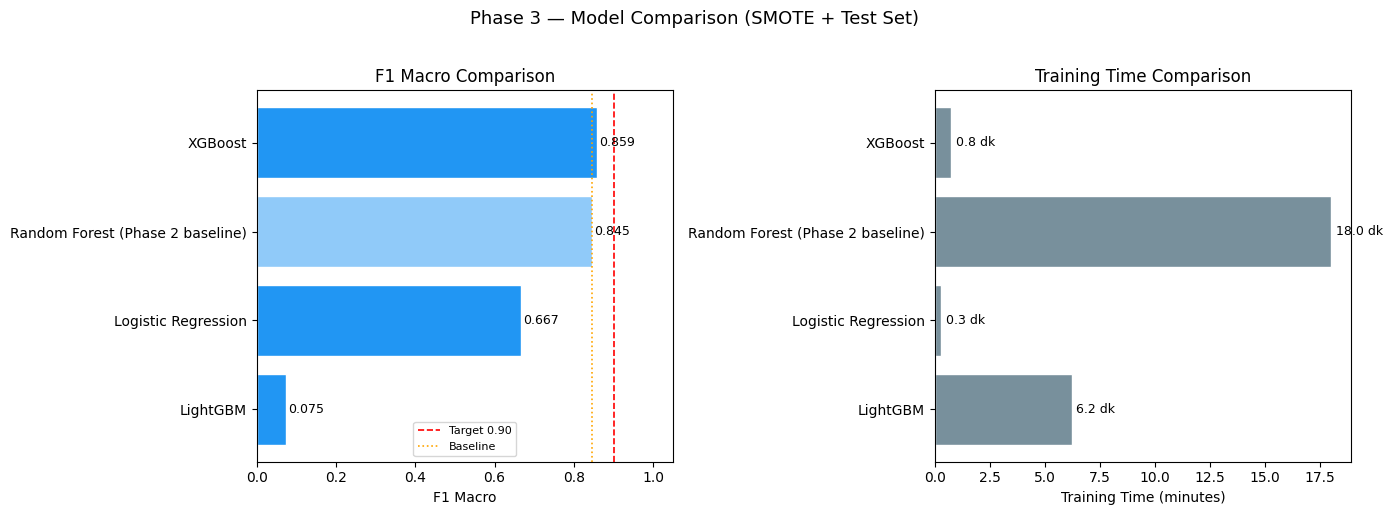

Saved → /content/drive/MyDrive/nids/outputs/figures/model_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Sol: F1 Macro bar ────────────────────────────────────────────────────
colors = ["#2196F3" if "baseline" not in m else "#90CAF9"
          for m in comparison_df["model"]]
axes[0].barh(comparison_df["model"], comparison_df["f1_macro"],
             color=colors, edgecolor="white")
axes[0].set_xlim(0, 1.05)
axes[0].axvline(0.90, color="red", linestyle="--", linewidth=1.2, label="Target 0.90")
axes[0].axvline(comparison_df.loc[comparison_df["model"].str.contains("baseline"), "f1_macro"].values[0],
                color="orange", linestyle=":", linewidth=1.2, label="Baseline")
for i, (val, _) in enumerate(zip(comparison_df["f1_macro"], comparison_df["model"])):
    axes[0].text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=9)
axes[0].set_xlabel("F1 Macro")
axes[0].set_title("F1 Macro Comparison")
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

# ── Right: Training time bar ───────────────────────────────────────────────
axes[1].barh(comparison_df["model"], comparison_df["train_time_m"],
             color="#78909C", edgecolor="white")
for i, val in enumerate(comparison_df["train_time_m"]):
    axes[1].text(val + 0.2, i, f"{val:.1f} dk", va="center", fontsize=9)
axes[1].set_xlabel("Training Time (minutes)")
axes[1].set_title("Training Time Comparison")
axes[1].invert_yaxis()

plt.suptitle("Phase 3 — Model Comparison (SMOTE + Test Set)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'model_comparison.png'}")

## 9. Results & Transition to Phase 4

Before running this cell, review the results above and update the commentary accordingly.

In [ ]:
best = comparison_df.iloc[0]
print("═" * 52)
print(f"  Best Model     : {best['model']}")
print(f"  F1 Macro       : {best['f1_macro']:.4f}")
print(f"  F1 Weighted    : {best['f1_weighted']:.4f}")
print(f"  ROC-AUC        : {best['roc_auc']:.4f}")
print(f"  Training time  : {best['train_time_m']:.1f} minutes")
print("═" * 52)
print(f"\nBaseline RF F1 Macro   : 0.8449")
delta = best['f1_macro'] - 0.8449
print(f"Improvement            : {delta:+.4f}")
print(f"\nModel to carry to Phase 4 → {best['model']}")

════════════════════════════════════════════════════
  Best Model     : XGBoost
  F1 Macro       : 0.8593
  F1 Weighted    : 0.9987
  ROC-AUC        : 1.0000
  Training time  : 0.8 minutes
════════════════════════════════════════════════════

Baseline RF F1 Macro   : 0.8449
Improvement            : +0.0144

Model to carry to Phase 4 → XGBoost


: 